# Quadtrix — Training Report
Parses the `.txt` training log and reproduces the three diagnostic plots:
1. **Loss Curves** — train loss & val loss vs iteration
2. **Val Loss vs Wall-clock Time** — elapsed seconds on x-axis
3. **Generalisation Gap** — (val − train) loss per eval step

In [1]:
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

In [2]:
# CONFIG 
LOG_FILE = "run_20260430_192930.txt"   # ← change path if needed

In [3]:

# Matches lines like:
#   train step=200/7000 pct=2.9% loss_train=4.9093 loss_val=4.9451 elapsed=2m 07s eta=71m 49s status=best saved
STEP_RE = re.compile(
    r"train step=(\d+)/\d+.*?"
    r"loss_train=([\d.]+).*?"
    r"loss_val=([\d.]+).*?"
    r"elapsed=(\d+)m\s+(\d+)s.*?"
    r"status=(.+)$"
)

steps, train_loss, val_loss, elapsed_s, saved_steps = [], [], [], [], []

log_text = Path(LOG_FILE).read_text(encoding="utf-8")

for line in log_text.splitlines():
    m = STEP_RE.search(line)
    if m:
        step   = int(m.group(1))
        lt     = float(m.group(2))
        lv     = float(m.group(3))
        secs   = int(m.group(4)) * 60 + int(m.group(5))
        status = m.group(6).strip()

        steps.append(step)
        train_loss.append(lt)
        val_loss.append(lv)
        elapsed_s.append(secs)
        if "best" in status:
            saved_steps.append(len(steps) - 1)   # index into the arrays

steps      = np.array(steps)
train_loss = np.array(train_loss)
val_loss   = np.array(val_loss)
elapsed_s  = np.array(elapsed_s)
gap        = val_loss - train_loss

best_idx   = np.argmin(val_loss)
best_step  = steps[best_idx]
best_val   = val_loss[best_idx]

print(f"Parsed {len(steps)} eval steps.")
print(f"Best val loss = {best_val:.4f} at step {best_step}")

FileNotFoundError: [Errno 2] No such file or directory: 'run_20260430_192930.txt'

TypeError: list indices must be integers or slices, not list

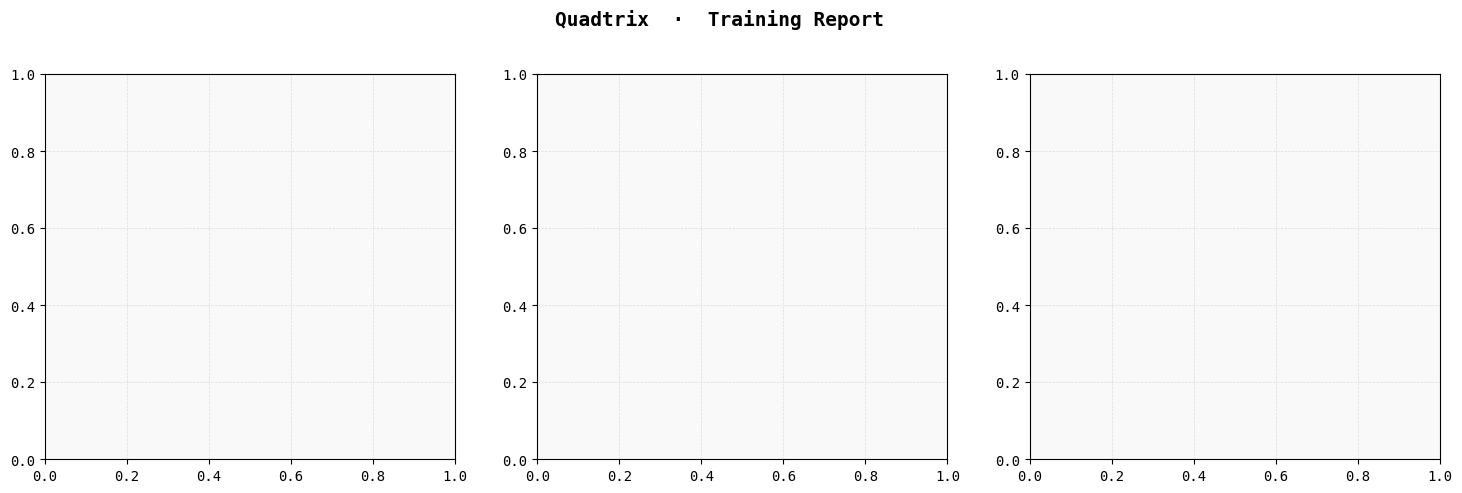

In [ ]:

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#f9f9f9",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Quadtrix  ·  Training Report", fontsize=14, fontweight="bold", y=1.01)

# Saved-checkpoint markers (indices)
sx = steps[saved_steps]
sy_val   = val_loss[saved_steps]
sy_train = train_loss[saved_steps]
sx_time  = elapsed_s[saved_steps]
sy_gap   = gap[saved_steps]

# 1. Loss Curves 
ax = axes[0]
ax.plot(steps, train_loss, color="steelblue",   lw=1.4, label="train loss")
ax.plot(steps, val_loss,   color="darkorange",  lw=1.4, label="val loss")
ax.scatter(sx, sy_val, color="limegreen", s=50, zorder=5, label="saved")

# Annotate best
ax.annotate(
    f"best val {best_val:.4f}\nstep {best_step}",
    xy=(best_step, best_val),
    xytext=(best_step - 600, best_val + 0.25),
    fontsize=7, color="green",
    arrowprops=dict(arrowstyle="->", color="green", lw=0.8),
)
ax.set_title("Loss Curves", fontsize=11)
ax.set_xlabel("iter")
ax.set_ylabel("cross-entropy loss")
ax.legend(fontsize=8)

#  2. Val Loss vs Wall-clock Time 
ax = axes[1]
ax.plot(elapsed_s, val_loss,   color="darkorange", lw=1.4, label="val loss")
ax.plot(elapsed_s, train_loss, color="steelblue",  lw=1.4, label="train loss")
ax.scatter(sx_time, sy_val, color="limegreen", s=50, zorder=5, label="saved")

best_time = elapsed_s[best_idx]
ax.annotate(
    f"best {best_val:.4f}\n({best_time//60:.0f}:{best_time%60:02.0f}min)",
    xy=(best_time, best_val),
    xytext=(best_time - 1200, best_val + 0.25),
    fontsize=7, color="green",
    arrowprops=dict(arrowstyle="->", color="green", lw=0.8),
)
ax.set_title("Val Loss vs Wall-clock Time", fontsize=11)
ax.set_xlabel("elapsed (seconds)")
ax.set_ylabel("cross-entropy loss")
ax.legend(fontsize=8)

# 3. Generalisation Gap
ax = axes[2]
ax.plot(steps, gap, color="mediumpurple", lw=1.4, label="val − train gap")
ax.fill_between(steps, gap, 0,
                where=(gap > 0), alpha=0.15, color="mediumpurple")
ax.fill_between(steps, gap, 0,
                where=(gap < 0), alpha=0.15, color="tomato")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.scatter(sx, sy_gap, color="limegreen", s=50, zorder=5, label="saved")

# Annotate peak gap
peak_idx = np.argmax(gap)
ax.annotate(
    f"peak gap {gap[peak_idx]:.4f}\nstep {steps[peak_idx]}",
    xy=(steps[peak_idx], gap[peak_idx]),
    xytext=(steps[peak_idx] - 800, gap[peak_idx] + 0.01),
    fontsize=7, color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=0.8),
)
# Annotate final gap
ax.annotate(
    f"final\n{gap[-1]:.4f}",
    xy=(steps[-1], gap[-1]),
    xytext=(steps[-1] - 900, gap[-1] - 0.03),
    fontsize=7, color="mediumpurple",
    arrowprops=dict(arrowstyle="->", color="mediumpurple", lw=0.8),
)

ax.set_title("Generalisation Gap  (val − train)", fontsize=11)
ax.set_xlabel("iter")
ax.set_ylabel("loss gap")
ax.legend(fontsize=8)

# Footer 
n_params = 6_684_497
vocab    = 105
fig.text(
    0.5, -0.03,
    f"params={n_params/1e6:.2f}M  |  vocab={vocab}  |  "
    f"tokens≈{7.1:.1f}M train / 0.8M val  |  "
    f"time={elapsed_s[-1]//60:.0f}min  |  best val={best_val:.4f}",
    ha="center", fontsize=8, color="#555"
)

plt.tight_layout()
plt.savefig("quadtrix_training_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → quadtrix_training_report.png")